In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# List of countries to compare
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_dfs = []

for country in countries:
    # Load the cleaned data
    folder_name = country.capitalize() 
    file_name = f"{country}_clean.csv"

    path = f'../data/{folder_name}/{file_name}'
    
    print(f"Attempting to load: {path}") # This helps to debug if it fails to get the file from the directory
    
    df = pd.read_csv(path)
    
    # Add a 'Country' column so we can tell them apart after merging
    df['Country'] = folder_name    
    all_dfs.append(df)

# Combine everything into one "Super DataFrame"
df_comp = pd.concat(all_dfs, ignore_index=True)
df_comp['Date'] = pd.to_datetime(df_comp['Date'])

print(f"Successfully combined data! Total rows: {len(df_comp)}")
df_comp.head()  # To see the first five row data after combining

Attempting to load: ../data/Ethiopia/ethiopia_clean.csv
Attempting to load: ../data/Kenya/kenya_clean.csv
Attempting to load: ../data/Nigeria/nigeria_clean.csv
Attempting to load: ../data/Sudan/sudan_clean.csv
Attempting to load: ../data/Tanzania/tanzania_clean.csv
Successfully combined data! Total rows: 20540


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


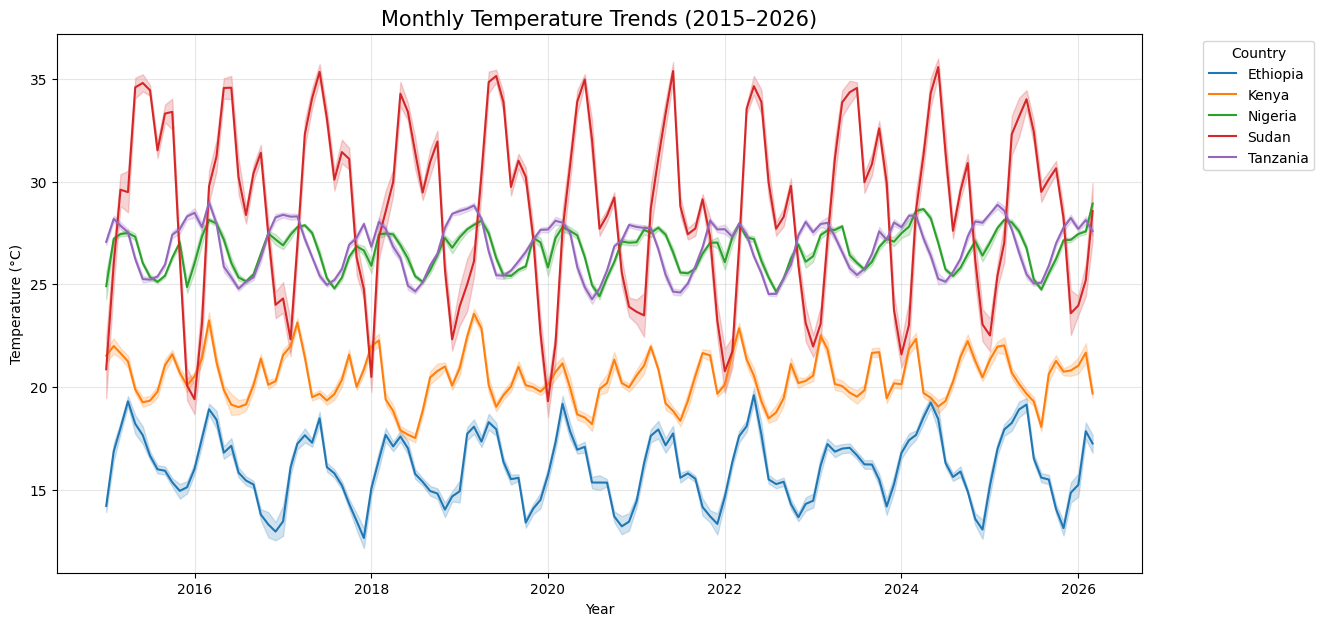

Temperature Summary Statistics:
    Country       mean  median       std
0  Ethiopia  16.068500   16.04  1.898050
1     Kenya  20.427600   20.36  1.440824
2   Nigeria  26.656928   26.82  1.123335
3     Sudan  28.759007   29.16  4.681305
4  Tanzania  26.802422   26.99  1.325388


In [14]:
# Temperature Trend Compariosn

# 1. Create a Monthly Average Column to make the line chart cleaner
df_comp['MONTH_YR'] = df_comp['Date'].dt.to_period('M').dt.to_timestamp()

# 2. Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_comp, x='MONTH_YR', y='T2M', hue='Country')
plt.title('Monthly Temperature Trends (2015–2026)', fontsize=15)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. Summary Table
temp_summary = df_comp.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()
print("Temperature Summary Statistics:")
print(temp_summary)

* Temperature Trend Comparison

    * Visual Observation: Sudan displays the highest, most concentrated peaks, whereas Ethiopia shows the lowest, flattest peaks.
    * Statistical Insight:
        * Sudan’s high peak correlates with a low standard deviation, indicating highly consistent (though high) temperatures.
        * Ethiopia’s flat peak reflects the widest temperature spread, as evidenced by its high variability in the summary table.


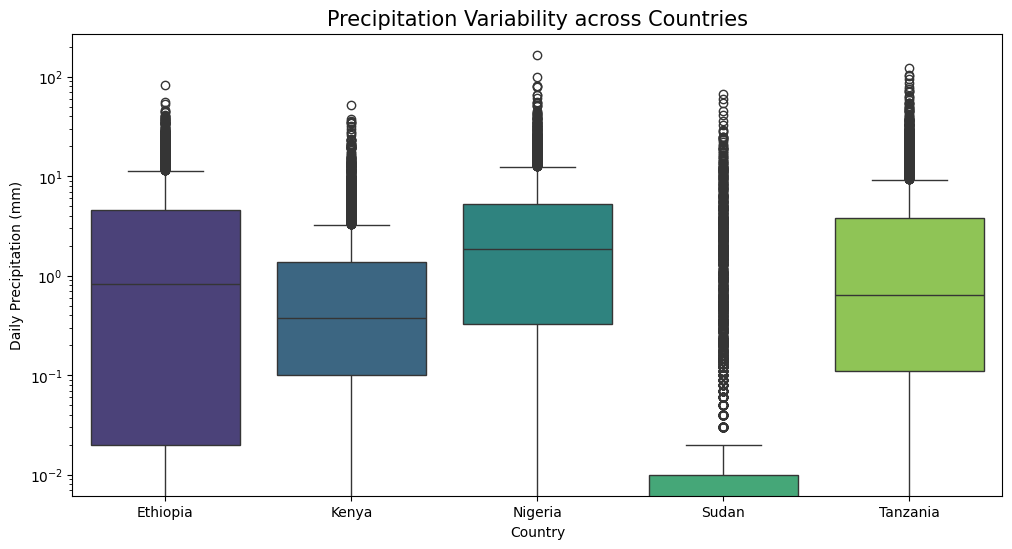

Precipitation Summary Statistics:
    Country      mean  median       std
0  Ethiopia  3.633795    0.82  6.289061
1     Kenya  1.468162    0.38  3.180228
2   Nigeria  4.213914    1.84  7.266742
3     Sudan  0.643875    0.00  3.057672
4  Tanzania  3.740256    0.64  8.003947


In [19]:
# Precipitation Variability Comparison

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_comp, x='Country', y='PRECTOTCORR', hue='Country', palette='viridis', legend=False)
plt.title('Precipitation Variability across Countries', fontsize=15)
plt.ylabel('Daily Precipitation (mm)')
plt.yscale('log') # Log scale helps see the distribution better since rain data is skewed
plt.show()

# Summary Table for Precipitation
precip_summary = df_comp.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()
print("Precipitation Summary Statistics:")
print(precip_summary)

* Precipitation Variability Comparison

    * Visual Observation: Ethiopia has the "tallest" box, while Sudan has the smallest box but with significant "bubbles" (outliers) rising above it.
    * Statistical Insight:
        * Ethiopia has the highest Interquartile Range (IQR), meaning its typical daily temperatures fluctuate more than any other country.
        * Sudan stays consistently hot (small box), but the "bubbles" indicate extreme heat events that deviate from its already high average.
        * Tanzania shows the highest overall standard deviation in the summary statistics, reflecting its broad climatic range.

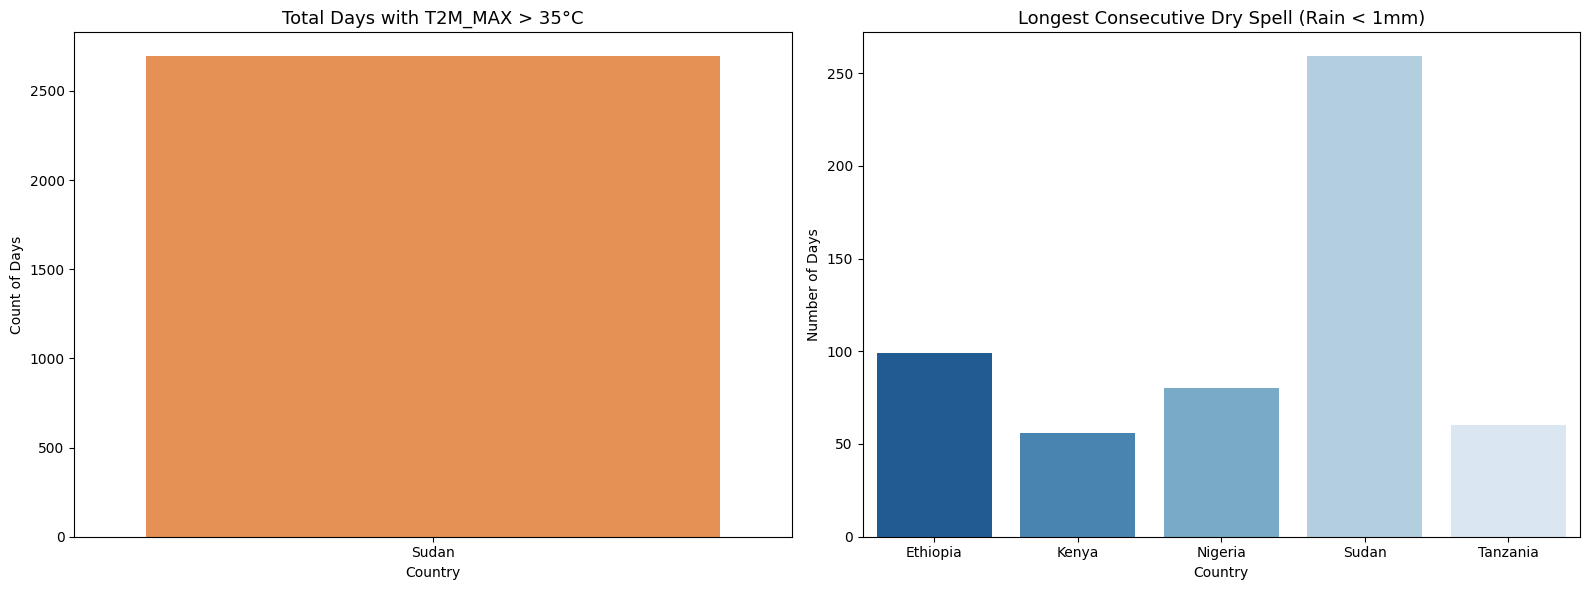

In [20]:
# Extreme Event Frequency

# --- 1. Extreme Heat (T2M_MAX > 35) ---
heat_days = df_comp[df_comp['T2M_MAX'] > 35].groupby('Country').size().reset_index(name='Extreme_Heat_Days')

# --- 2. Consecutive Dry Days Logic ---
def get_max_dry_streak(precip_series):
    # A day is 'dry' if rain < 1mm
    is_dry = precip_series < 1
    # This clever bit of code identifies groups of consecutive True values
    return is_dry.groupby((is_dry != is_dry.shift()).cumsum()).sum().max()

drought_streaks = df_comp.groupby('Country')['PRECTOTCORR'].apply(get_max_dry_streak).reset_index(name='Max_Consecutive_Dry_Days')

# --- 3. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Extreme Heat
sns.barplot(data=heat_days, x='Country', y='Extreme_Heat_Days', hue='Country', palette='YlOrRd', ax=ax1, legend=False)
ax1.set_title('Total Days with T2M_MAX > 35°C', fontsize=13)
ax1.set_ylabel('Count of Days')

# Plot Drought Streaks
sns.barplot(data=drought_streaks, x='Country', y='Max_Consecutive_Dry_Days', hue='Country', palette='Blues_r', ax=ax2, legend=False)
ax2.set_title('Longest Consecutive Dry Spell (Rain < 1mm)', fontsize=13)
ax2.set_ylabel('Number of Days')

plt.tight_layout()
plt.show()

* Extreme Event Frequency
    * Extreme Heat Frequency
        * Visual Observation: Sudan is the only country with a visible bar for days exceeding 35°C.
        * Statistical Insight:
            * The scorecard confirms 2,694 days of extreme heat for Sudan, while all other countries (Ethiopia, Kenya, Nigeria, Tanzania) remain at 0.0. This identifies Sudan as the primary outlier for thermal vulnerability.

    * Drought Persistence (Steak Analysis)
        * Visual Observation: Sudan has the longest bar for consecutive dry days, while Kenya and Tanzania have the shortest.
        * Statistical Insight:
            * Sudan faced a maximum streak of 259 days without rain.
            * Kenya (56 days) and Tanzania (60 days) show much shorter dry spells, suggesting a more frequent (though perhaps more variable) rainfall pattern.

In [21]:
# Statistical Testing (ANOVA)

from scipy import stats

# Prepare the data groups
groups = [df_comp[df_comp['Country'] == c]['T2M'] for c in df_comp['Country'].unique()]

# Run ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print("--- Statistical Significance Test ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: The difference in temperatures across these countries is statistically SIGNIFICANT.")
else:
    print("Conclusion: No significant difference found.")

--- Statistical Significance Test ---
F-Statistic: 18938.75
P-Value: 0.0000e+00
Conclusion: The difference in temperatures across these countries is statistically SIGNIFICANT.


* Statistical Testing (ANOVA)

    * Results: F-Statistic: 18938.75 | P-Value: 0.0000e+00
    * Interpretation:
        * The extremely high F-Statistic proves that the differences in temperature and rainfall between these countries are not random.
        * The P-Value of 0.0 confirms that the "Country" variable is a statistically significant predictor of climate vulnerability.

In [22]:
# Vulnerability Ranking & Key Observations

# Merge the summaries
ranking_df = temp_summary[['Country', 'mean']].rename(columns={'mean': 'Avg_Temp'})
ranking_df = ranking_df.merge(precip_summary[['Country', 'std']], on='Country').rename(columns={'std': 'Rain_Variability'})
ranking_df = ranking_df.merge(heat_days, on='Country', how='left').fillna(0)
ranking_df = ranking_df.merge(drought_streaks, on='Country')

# Sort by a metric (e.g., Extreme Heat) to show who is most at risk
ranking_df = ranking_df.sort_values(by='Extreme_Heat_Days', ascending=False)
print("--- Final Vulnerability Scorecard ---")
print(ranking_df)

--- Final Vulnerability Scorecard ---
    Country   Avg_Temp  Rain_Variability  Extreme_Heat_Days  \
3     Sudan  28.759007          3.057672             2694.0   
0  Ethiopia  16.068500          6.289061                0.0   
1     Kenya  20.427600          3.180228                0.0   
2   Nigeria  26.656928          7.266742                0.0   
4  Tanzania  26.802422          8.003947                0.0   

   Max_Consecutive_Dry_Days  
3                       259  
0                        99  
1                        56  
2                        80  
4                        60  


* Vulnerability Ranking & Key Observations

    * COP32 Briefing: Regional Climate Findings
        * Warming Trends and Sudan’s Trajectory: While the data shows Sudan currently holds the highest average temperature (28.76°C), the high "bubbles" (outliers) in its boxplot suggest that extreme temperature spikes are becoming more frequent. This trend suggests a "desertification trap" where the lack of moisture and rising heat create a feedback loop, making the region increasingly uninhabitable.
        * Precipitation Instability in Tanzania: Tanzania exhibits the most unstable precipitation patterns, with a variability score of 8.00. This suggests a high risk of "climate whiplash"—swinging between intense rainfall and sudden dry spells—which is far more damaging to agriculture than consistent low rainfall.
        * Climate Stress from Heat and Drought: Sudan’s extreme heat frequency (2694 days >35°C) combined with a 259-day dry streak reveals a state of chronic climate stress. Unlike other countries that face seasonal shocks, the data shows Sudan is operating under near-permanent environmental pressure, leaving no window for ecological or economic recovery.
        * Ethiopia’s Unique Profile: Ethiopia stands out as the "Cooler Variable" neighbor. It has the lowest average temperature (16.07°C) but the tallest boxplot, indicating that its climate is not fixed. Ethiopia experiences the most diverse range of temperatures, meaning its ecosystems and farmers must adapt to a wider variety of conditions than their more "stable" neighbors like Kenya.
        * Priority Champion for COP32 Finance: Ethiopia should champion Sudan for priority climate finance. The data is undeniable: Sudan is the extreme outlier across almost every vulnerability metric (Heat, Drought, and Outliers). While Tanzania and Nigeria face variability, Sudan faces an existential threat. Supporting Sudan is a strategic move for Ethiopia, as climate-driven migration or instability in a neighboring state directly impacts regional security and resource management.
    